# Kerr oscilator model

This model describes a single photonic mode subject to photon-photon interaction U, two-photon drive F , and losses $\gamma$. We work here in the frequency frame of the drive,
such that $\Delta = \omega_0 − \omega_d$ , where $\omega_0$ is the mode bare frequency and $\omega_d$ is the drive frequency. It is well known to display bistability , i.e., the coexistence of two stablesteady-state solutions at mean-field level, which seemed tocontradict the necessary uniqueness of the quantum ground state. [1]


When two photon driving is used, the system has a parity symmetry; it has been shown theoretically that this symmetry can be spontaneously broken in the steady state, leading to a continuous phase transition. Recently, this symmetry breaking has found applications in quantum error correction . Furthermore, phase transitions in either a few or a lattice of coupled Kerr oscillators have also been explored. Dissipative phase transitions have also been studied in a dissipative cavity with other types of nonlinearity, such as coupling with atoms. [2]

Previous approaches to the phase transition in a Kerr oscillator are usually limited to finite system size. Here, using the Keldysh formalism, we access the thermodynamic limit directly. [2]

[1] : Analytical phase boundary of a quantum driven-dissipative Kerr oscillator from classical stochastic instantons https://journals.aps.org/prresearch/pdf/10.1103/528d-l76d 

[2] : Driven-dissipative phase transition in a Kerr oscillator: From semiclassical PT symmetry to quantum fluctuations https://sci-hub.mx/10.1103/PhysRevA.103.033711

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset


# Parametros]
N = 100              # dim Hilbert space
Delta = 0.5         # Detuning
U = 1.5             # Interaction
F = 0.2             # Drive
gamma = 0.3         # Loss

# Operadores
a = destroy(N)  
H = - Delta*a.dag()*a + (U/2)*a.dag()*a.dag()*a*a + F*(a.dag() + a)
S = [np.sqrt(gamma)*a]

# Liouvillian

L = liouvillian(H, S)
eigs = L.eigenenergies()


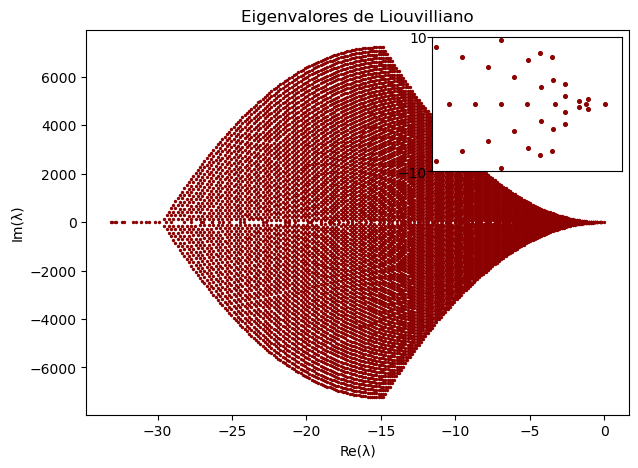

In [43]:
X = np.real(eigs)
Y = np.imag(eigs)

fig, ax = plt.subplots(figsize=(7,5))

# Grafica principal
ax.scatter(X, Y, s=2, c='darkred')
ax.set_xlabel("Re(λ)")
ax.set_ylabel("Im(λ)")
ax.set_title("Eigenvalores de Liouvilliano")

# -------------------------
# Zoom
# -------------------------
axins = inset_axes(ax, width="35%", height="35%", loc='upper right')

axins.scatter(X, Y, s=7, c='darkred')

# Limites de la region a ampliar
x1, x2 = -2, 0.2
y1, y2 = -10, 10

axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)

# Opcional: quitar labels pequeños
axins.tick_params(axis='y',
                  direction='out',
                  labelsize=10,
                  pad=0)
axins.set_xticks([])
axins.set_yticks([-10,10])


plt.show()